In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Setup Formatter and Handlers
log_formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

file_handler = logging.FileHandler('Unsup_ML.log', mode='a')
file_handler.setFormatter(log_formatter)
file_handler.setLevel(logging.INFO)

stream_handler = logging.StreamHandler()
stream_handler.setFormatter(log_formatter)
stream_handler.setLevel(logging.INFO)

# 2. Configure Root Logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(file_handler)
logger.addHandler(stream_handler)

sns.set(style='darkgrid')
warnings.filterwarnings('ignore')
%matplotlib inline


In [17]:
df_model = pd.read_csv(r'C:/Users/Sadanand/OneDrive/NUS AI and ML Course\\00 Capstone Project/capstone_projct_shrikant/data/ml_Metro_Interstate_Traffic_Volume.csv')
df_model.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,...,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm,congestion_category,high_risk
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,...,0,0,0,0,0,0,0,0,Severe,0
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,0,0,0,0,0,0,0,0,High,0
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,...,0,0,0,0,0,0,0,0,High,0
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,...,0,0,0,0,0,0,0,0,Severe,0
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,...,0,0,0,0,0,0,0,0,High,0


In [18]:
# Capturing df.info() output into logger
import io
buffer = io.StringIO()
df_model.info(buf=buffer)
s = buffer.getvalue()
logger.info("DataFrame Info:\n%s", s)

2026-09-27 15:33:08,238 - INFO - DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48187 entries, 0 to 48186
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   holiday                    48187 non-null  object 
 1   temp                       48187 non-null  float64
 2   rain_1h                    48187 non-null  float64
 3   snow_1h                    48187 non-null  float64
 4   clouds_all                 48187 non-null  int64  
 5   weather_main               48187 non-null  object 
 6   weather_description        48187 non-null  object 
 7   date_time                  48187 non-null  object 
 8   traffic_volume             48187 non-null  int64  
 9   hour                       48187 non-null  int64  
 10  day_of_week                48187 non-null  int64  
 11  month                      48187 non-null  int64  
 12  is_weekend                 48187 non-null  int64  
 1

In [19]:
logger.info("DataFrame Description:\n%s", df_model.describe())

2026-09-27 15:33:08,400 - INFO - DataFrame Description:
               temp       rain_1h       snow_1h    clouds_all  traffic_volume  \
count  48187.000000  48187.000000  48187.000000  48187.000000    48187.000000   
mean     281.260329      0.130358      0.000222     49.365451     3259.618134   
std       12.710322      1.003542      0.008169     39.015213     1986.954465   
min      243.390000      0.000000      0.000000      0.000000        0.000000   
25%      272.160000      0.000000      0.000000      1.000000     1192.500000   
50%      282.450000      0.000000      0.000000     64.000000     3379.000000   
75%      291.806000      0.000000      0.000000     90.000000     4933.000000   
max      310.070000     55.630000      0.510000    100.000000     7280.000000   

               hour   day_of_week         month    is_weekend      hour_sin  \
count  48187.000000  48187.000000  48187.000000  48187.000000  4.818700e+04   
mean      11.397742      2.984913      6.505240      0.2

2026-09-27 15:33:08,617 - INFO - Correlation matrix plotted successfully.


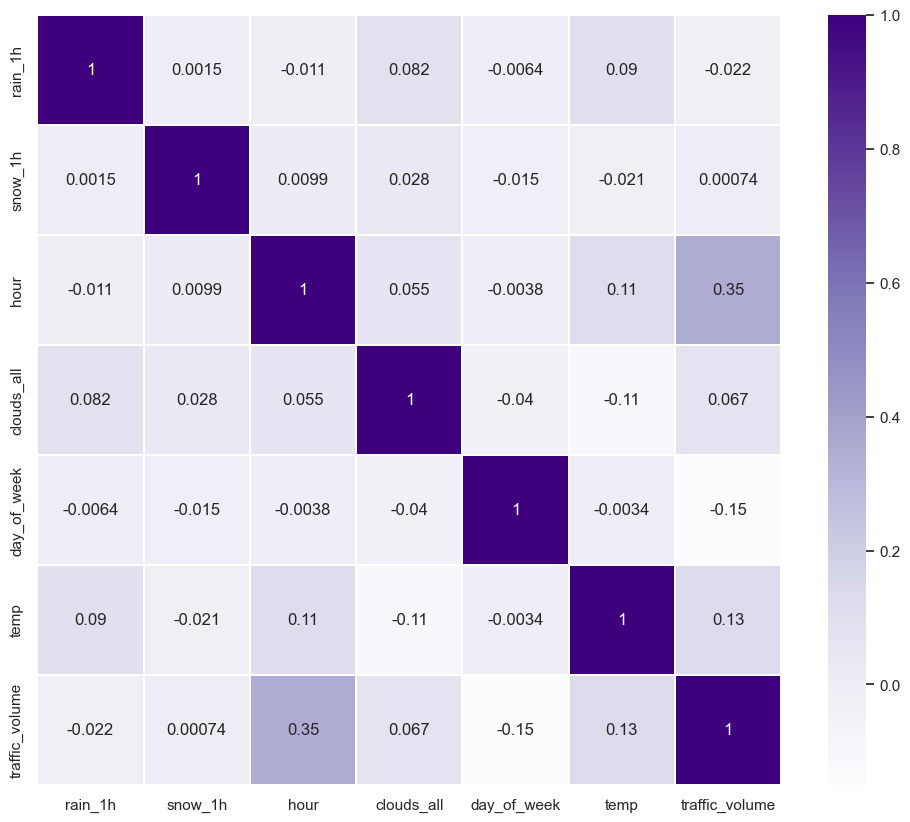

In [20]:
# --- Seperating Variables for EDA ---
df_num = df_model[['rain_1h', 'snow_1h', 'hour', 'clouds_all','day_of_week','temp','traffic_volume']]

# --- Correlation Map (Heatmap) ---
plt.figure(figsize = (12, 10))
sns.heatmap(df_num.corr(), annot = True, cmap = 'Purples', linewidths = 0.12)
logger.info("Correlation matrix plotted successfully.")

In [21]:
ind = df_model.iloc[:,[1,2,3,4]].values
logger.info("Selected independent feature values at index 7: %s", ind[7])

2026-09-27 15:33:08,932 - INFO - Selected independent feature values at index 7: [293.86   0.     0.     1.  ]


2026-09-27 15:39:53,382 - INFO - K-Means Elbow Curve
2026-09-27 15:39:53,384 - INFO - Cluster Numbers (K): 2
2026-09-27 15:39:53,474 - INFO - Cluster Numbers (K): 3
2026-09-27 15:39:53,667 - INFO - Cluster Numbers (K): 4
2026-09-27 15:39:53,901 - INFO - Cluster Numbers (K): 5
2026-09-27 15:39:54,150 - INFO - Cluster Numbers (K): 6
2026-09-27 15:39:54,448 - INFO - Cluster Numbers (K): 7
2026-09-27 15:39:54,768 - INFO - WCSS completed
2026-09-27 15:39:54,785 - INFO - Elbow curve completed


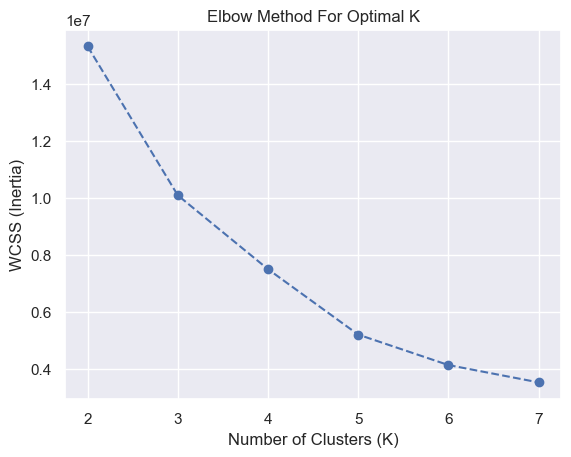

In [31]:
wcss = []
k_range = range(2, 8)

try:
    logger.info("K-Means Elbow Curve")
    if np.any(pd.isna(ind)):
        raise ValueError("NaN values found in the input data. Please clean the data first.")
        
    for i in k_range:
        
        logger.info(f"Cluster Numbers (K): {i}")
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=200, n_init=8, random_state=0)
        kmeans.fit(ind)
        wcss.append(kmeans.inertia_)
        
    logger.info("WCSS completed")
    plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
    plt.title('Elbow Method For Optimal K')
    plt.xlabel('Number of Clusters (K)')
    ylabel_text = plt.ylabel('WCSS (Inertia)')
    logger.info("Elbow curve completed")
except ValueError as val_err:
    logger.error(f"Data Validation Error: {val_err}")
except RuntimeError as run_err:
   
    logger.error(f"K-Means Runtime Error: {run_err}")
except Exception as e:
    
    logger.error(f"Unexpected Error during K-Means: {e}", exc_info=True)


In [23]:
try:
    logger.info("K=4 ")
    kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=200, n_init=8, random_state=0)
    y_kmeans = kmeans.fit_predict(ind)
    logger.info("Shape: %s", y_kmeans.shape)
except Exception as e:
    logger.error("Final K-Means prediction error: %s", e)

2026-09-27 15:33:10,766 - INFO - K=4 
2026-09-27 15:33:10,989 - INFO - Shape: (48187,)


In [24]:
df_pred_clusters = df_model.copy()
df_pred_clusters['Clusters'] = y_kmeans
logger.info(" df_pred_clusters DataFrame Head:\n%s", df_pred_clusters.head(10))

2026-09-27 15:33:11,023 - INFO -  df_pred_clusters DataFrame Head:
      holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0  No Holiday  288.28      0.0      0.0          40       Clouds   
1  No Holiday  289.36      0.0      0.0          75       Clouds   
2  No Holiday  289.58      0.0      0.0          90       Clouds   
3  No Holiday  290.13      0.0      0.0          90       Clouds   
4  No Holiday  291.14      0.0      0.0          75       Clouds   
5  No Holiday  291.72      0.0      0.0           1        Clear   
6  No Holiday  293.17      0.0      0.0           1        Clear   
7  No Holiday  293.86      0.0      0.0           1        Clear   
8  No Holiday  294.14      0.0      0.0          20       Clouds   
9  No Holiday  293.10      0.0      0.0          20       Clouds   

  weather_description            date_time  traffic_volume  hour  ...  \
0    scattered clouds  2012-10-02 09:00:00            5545     9  ...   
1       broken clouds  2012-10-02 10:0

In [25]:
logger.info("Cluster value counts):\n%s", df_pred_clusters.value_counts('Clusters'))

2026-09-27 15:33:11,127 - INFO - Cluster value counts):
Clusters
1    24773
3    11648
2     6620
0     5146
Name: count, dtype: int64


2026-09-27 15:33:12,501 - INFO - Jointplot plotted successfully.


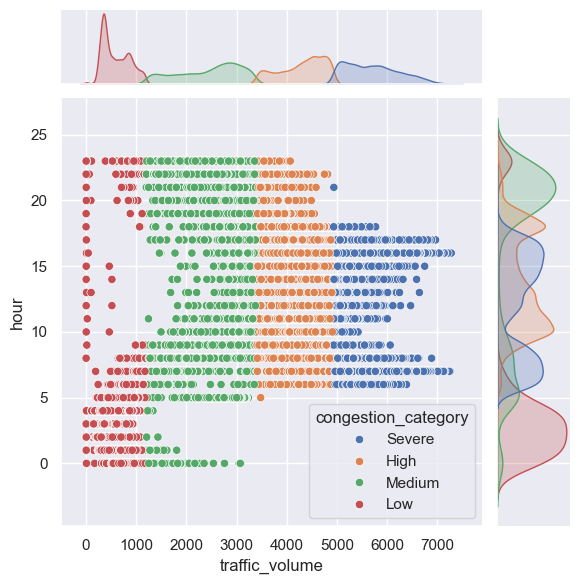

In [26]:
sns.jointplot(x='traffic_volume', y='hour', data=df_model, hue='congestion_category')
logger.info("Jointplot plotted successfully.")

In [27]:
logger.info("Congestion Category Value Counts:\n%s", df_model.value_counts('congestion_category'))

2026-09-27 15:33:15,703 - INFO - Congestion Category Value Counts:
congestion_category
High      12054
Medium    12049
Low       12047
Severe    12037
Name: count, dtype: int64


In [32]:
try:
    logger.info("Association Rule Mining (ARM) processing started.")
    df_arm = pd.DataFrame()
    df_arm['time_of_day'] = pd.cut(df_model['hour'], bins=[-1, 6, 9, 16, 19, 24], 
                                   labels=['Night', 'Morning_Peak', 'Midday', 'Evening_Peak', 'Late_Night'])
    df_arm['weekday_type'] = df_model['day_of_week'].apply(lambda x: 'Weekday' if x < 5 else 'Weekend')
    df_arm['weather'] = df_model['weather_description']
    df_arm['congestion_level'] = pd.qcut(df_model['traffic_volume'], q=3, 
                                         labels=['Low_Congestion', 'Medium_Congestion', 'High_Congestion'])

    df_encoded = pd.get_dummies(df_arm, dtype=bool)
    
    logger.info("Running Apriori algorithm...")
    frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    
    target_rules = rules[rules['consequents'].apply(lambda x: 'congestion_level_High_Congestion' in list(x))]
    top_lift_rules = target_rules.sort_values(by='lift', ascending=False).head(5)
    
  
    rules_summary = top_lift_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    logger.info(f"Top Lift Rules for High Congestion:\n{rules_summary}")

except Exception as e:
    logger.error(f"Association Rule Mining error: {e}", exc_info=True)


2026-09-27 15:41:45,684 - INFO - Association Rule Mining (ARM) processing started.
2026-09-27 15:41:45,730 - INFO - Running Apriori algorithm...
2026-09-27 15:41:45,817 - INFO - Top Lift Rules for High Congestion:
                                           antecedents  \
80    (weekday_type_Weekday, time_of_day_Morning_Peak)   
175  (time_of_day_Midday, weekday_type_Weekday, wea...   
180  (weather_sky is clear, time_of_day_Midday, wee...   
90          (time_of_day_Midday, weekday_type_Weekday)   
102     (time_of_day_Midday, weather_scattered clouds)   

                            consequents   support  confidence      lift  
80   (congestion_level_High_Congestion)  0.081474    0.893491  2.681030  
175  (congestion_level_High_Congestion)  0.021873    0.820233  2.461211  
180  (congestion_level_High_Congestion)  0.033162    0.809524  2.429076  
90   (congestion_level_High_Congestion)  0.156972    0.766285  2.299332  
102  (congestion_level_High_Congestion)  0.020234    0.702450  2.10

In [29]:
try:
    top_lift_rules.to_csv('traffic_rules.csv', index=False)
    logger.info("Rules saved to'traffic_rules.csv' .")
except Exception as e:
    logger.error("CSV file save error: %s", e)

2026-09-27 15:33:16,117 - INFO - Rules saved to'traffic_rules.csv' .
